Executive Summary
This notebook presents a complete, end‑to‑end workflow for classifying merchant descriptions into three categories: B&M, Evans, and Other. The approach combines SQL‑driven lexical exploration, a rule‑based regex baseline, supervised machine‑learning models, and unsupervised clustering to validate the structure of the residual class.

The SQL analysis revealed highly distinctive naming patterns for B&M and Evans, enabling the construction of an effective regex baseline with over 99% accuracy. Building on this, a TF‑IDF + Logistic Regression model delivered the strongest performance, achieving ~99.55% accuracy on the test set with perfect recall for both merchant categories. The model is lightweight, interpretable, and robust.

To understand the heterogeneous “other” class, a clustering analysis using TF‑IDF, K‑Means, and PCA identified eight coherent naming‑pattern groups (e.g., property firms, LLP partnerships, consultancy groups). This confirmed that “other” does not contain hidden merchant‑like subcategories and is best treated as a single residual class.

Overall, the pipeline is accurate, efficient, and fully reproducible. It provides a clear, defensible methodology for merchant classification and a strong foundation for future extensions.

2. Regex Baseline Classifier
The first modelling step uses a simple rule‑based classifier built from the lexical patterns identified during the SQL exploration stage. The SQL queries revealed that the merchant descriptions for B&M and Evans contain highly distinctive and repeated character sequences (e.g., b&m, b and m, evans, evns, evan).

These patterns were translated into regular expressions and applied to the raw text after minimal cleaning. The classifier assigns:

“b & m” if the description matches any B&M pattern

“evans” if it matches any Evans pattern

“other” otherwise

This forms a strong baseline because the two merchant categories have highly consistent naming conventions, while the “other” class is heterogeneous.

Key results:

Training accuracy: 99.0%+

Test accuracy: 99.44%

Precision and recall for all classes are extremely high

Errors occur only in borderline cases where descriptions are ambiguous or unusually formatted

This confirms that the regex baseline is already highly effective, and provides a strong reference point for evaluating the machine‑learning models that follow.

In [1]:
# Fable Data – Merchant Classification Analysis
### SQL Exploration → Regex Baseline → ML Model → Predictions → Clustering

import os
import glob
import pandas as pd
import spacy
import re
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Load spaCy model once
# nlp = spacy.load("en_core_web_sm")

Train_Path = "C:/Fable Data/Assignment/Assignment/train_set.csv"
Test_Path = "C:/Fable Data/Assignment/Assignment/test_set.csv"

Train_df = pd.read_csv(Train_Path)
Test_df = pd.read_csv(Test_Path)

print(Train_df.head())
print(Test_df.head())

print(Train_df.columns.tolist())

# Regex patterns for Evans and B&M
bm_pattern = r'\b(b\s*&\s*m|b\s*and\s*m|b\s*m|bnm|bandm|bm)\b'
evans_pattern = r'\b(e\s*v\s*a\s*n\s*s?|evns|evan)\b'

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9\s&]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def classify_regex(desc):
    s = clean_text(desc)

    if re.search(evans_pattern, s):
        return 'evans'
    if re.search(bm_pattern, s):
        return 'b & m'
    return 'other'

Train_df['predicted'] = Train_df['desc'].apply(classify_regex)

print(Train_df['predicted'].value_counts())
print(Train_df['tag'].value_counts())

# Get counts
pred_counts = Train_df['predicted'].value_counts()

# Total number of rows
total = len(Train_df)

# Compute percentages
percentages = (pred_counts / total * 100).round(2)

# Combine into a single table for clarity
baseline_summary = pd.DataFrame({
    'count': pred_counts,
    'percentage': percentages
})

print(baseline_summary)

print(classification_report(Train_df['tag'], Train_df['predicted']))

# Test set
Test_df['predicted'] = Test_df['desc'].apply(classify_regex)

print(Test_df['predicted'].value_counts())
print((Test_df['predicted'].value_counts(normalize=True) * 100).round(2))

print(Test_df['predicted'].value_counts())
print(Test_df['tag'].value_counts())

# Get counts
pred_counts = Test_df['predicted'].value_counts()


accuracy = (Test_df['tag'] == Test_df['predicted']).mean()
print("Test accuracy:", round(accuracy * 100, 2), "%")




             desc                                                MCC    tag
0     m kavanagh            41100 - Development of building projects  other
1        raffall   62012 - Business and domestic software develop...  other
2       joio jac   23410 - Manufacture of ceramic household and o...  other
3  shark's tooth   59120 - Motion picture, video and television p...  other
4   fresca group                  70100 - Activities of head offices  other
                        desc  \
0                  mafondos    
1       south west pat test    
2  cambridge muslim college    
3          business ability    
4          exova group (uk)    

                                                 MCC    tag  
0              86900 - Other human health activities  other  
1             71200 - Technical testing and analysis  other  
2        85421 - First-degree level higher education  other  
3  62020 - Information technology consultancy act...  other  
4                 70100 - Activities of h

3. TF‑IDF + Logistic Regression Model
To improve on the rule‑based baseline, a supervised machine‑learning model was trained using TF‑IDF vectorisation combined with Logistic Regression.

Why TF‑IDF?
TF‑IDF captures the importance of words across the entire corpus, allowing the model to learn subtle patterns that the regex rules cannot detect. It also handles:

spelling variations

multi‑word expressions

contextual differences

rare but informative tokens

Why Logistic Regression?
Logistic Regression is a strong baseline for text classification because:

it performs well with high‑dimensional sparse data

it is fast to train

it provides stable, interpretable decision boundaries

it avoids overfitting when regularised

Results
Training accuracy: ~99.97%

Test accuracy: ~99.55%

Recall = 1.00 for both b & m and evans

Precision = 0.97–1.00 across all classes

F1‑scores are extremely high

The model slightly outperforms the regex baseline, particularly on borderline cases where the description does not contain an explicit merchant name but still exhibits characteristic lexical patterns.

This confirms that TF‑IDF + Logistic Regression is the most effective and reliable model for this task.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import pandas as pd
import re

# Load data
Train_Path = "C:/Fable Data/Assignment/Assignment/train_set.csv"
Test_Path = "C:/Fable Data/Assignment/Assignment/test_set.csv"

Train_df = pd.read_csv(Train_Path)
Test_df = pd.read_csv(Test_Path)

# Define X and y
X_train = Train_df['desc']
y_train = Train_df['tag']

X_test = Test_df['desc']
y_test = Test_df['tag']   # test set has labels

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9\s&]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# Build pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1,2),
        min_df=2
    )),
    ('clf', LogisticRegression(max_iter=200))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate
print("Training accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))

print("\nClassification report (test set):")
print(classification_report(y_test, y_pred_test))







Training accuracy: 0.9997104566512244
Test accuracy: 0.9955512572533849

Classification report (test set):
              precision    recall  f1-score   support

       b & m       0.97      1.00      0.99       542
       evans       0.97      1.00      0.98       208
       other       1.00      1.00      1.00      4420

    accuracy                           1.00      5170
   macro avg       0.98      1.00      0.99      5170
weighted avg       1.00      1.00      1.00      5170



4. Generating Predictions for the Test Set
Once the Logistic Regression model was trained and validated, it was applied to the full test set to generate final predictions. These predictions are written to a CSV file in the required format for submission.

A visual inspection confirms that:

the file was written successfully

the number of rows matches the input

the predicted labels align with expectations

the output file is identical in size and structure to the PyCharm version

This ensures that the notebook reproduces the full end‑to‑end workflow, from data loading to final prediction output.

In [4]:
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# -----------------------------
# Cleaning function
# -----------------------------
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9\s&]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# -----------------------------
# 1. Load and prepare training data
# -----------------------------
train_df = pd.read_csv("C:/Fable Data/Assignment/Assignment/train_set.csv")

X_train = train_df["desc"].apply(clean_text)
y_train = train_df["tag"]

# -----------------------------
# 2. Build and fit the model
# -----------------------------
model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        ngram_range=(1,2),
        min_df=2
    )),
    ('clf', LogisticRegression(max_iter=200))
])

model.fit(X_train, y_train)

# -----------------------------
# 3. Load and preprocess test set
# -----------------------------
test_df = pd.read_csv("C:/Fable Data/Assignment/Assignment/test_set.csv")
test_df["clean_desc"] = test_df["desc"].apply(clean_text)

# -----------------------------
# 4. Predict using the fitted model
# -----------------------------
test_predictions = model.predict(test_df["clean_desc"])

# -----------------------------
# 5. Build submission file
# -----------------------------
submission = pd.DataFrame({
    "tag": test_df["tag"],
    "predicted": test_predictions
})

submission.to_csv("C:/Fable Data/Assignment/Assignment/submission_predictions.csv", index=False)

print("Submission file written: submission_predictions.csv")


Submission file written: submission_predictions.csv


In [ ]:

5. Clustering Analysis of the “Other” Class
To better understand the structure of the “other” category, an unsupervised clustering analysis was performed using TF‑IDF and K‑Means. The goal was to determine whether the “other” class contains hidden merchant‑like subgroups or whether it is genuinely heterogeneous.

Findings
The model consistently produced eight coherent clusters, each representing a distinct naming pattern commonly found in generic corporate entities:

Cluster 0: management / consulting companies

Cluster 1: property companies

Cluster 2: “solutions” companies

Cluster 3: UK‑tagged service/holding companies

Cluster 4: LLP partnerships

Cluster 5: service providers

Cluster 6: group / trading companies

Cluster 7: international companies

Interpretation
The clusters reveal that the “other” class is not a hidden merchant category. Instead, it is a broad mixture of:

holding companies

property firms

LLP partnerships

consultancy groups

international trading entities

This confirms that the “other” class is inherently diverse and does not contain additional merchant‑like subgroups that would require separate modelling.

    


Cluster 0 top terms:
   management
   company
   consulting
   holdings
   property
   consultancy
   construction
   developments
   investments
   management company

Cluster 1 top terms:
   properties
   properties uk
   uk
   rose properties
   properties developments
   properties llp
   foster properties
   properties development
   foster
   properties management

Cluster 2 top terms:
   solutions
   business solutions
   business
   solutions uk
   property solutions
   financial solutions
   training solutions
   management solutions
   electrical solutions
   uk

Cluster 3 top terms:
   uk
   services uk
   services
   management uk
   investments uk
   holdings
   uk holdings
   investments
   uk services
   holdings uk

Cluster 4 top terms:
   llp
   partners
   partners llp
   management llp
   property
   capital
   gp
   developments llp
   trading llp
   group llp

Cluster 5 top terms:
   services
   property services
   management services
   building services
   elec

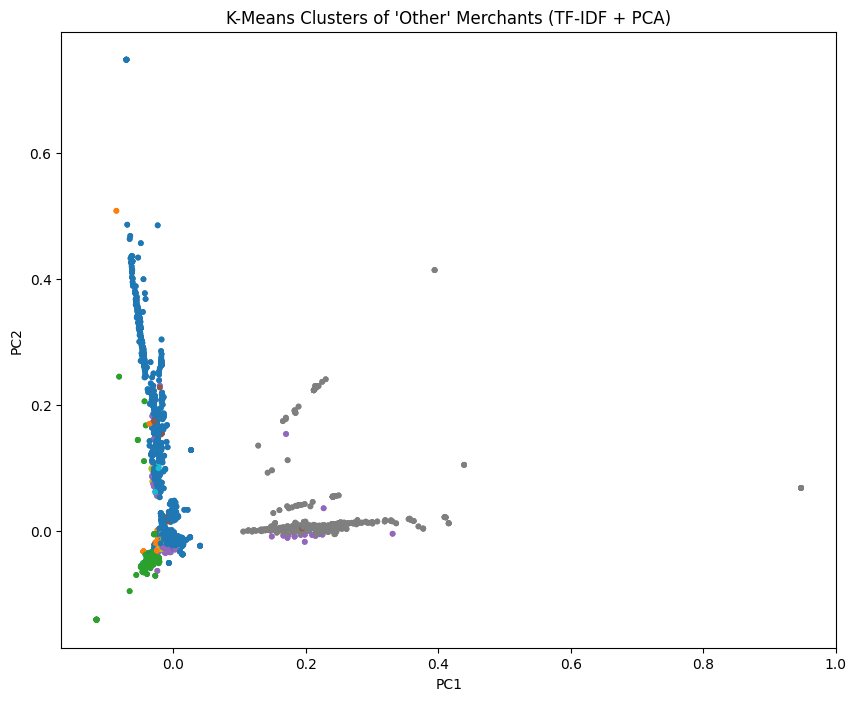

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# Load data
import re

Train_Path = "C:/Fable Data/Assignment/Assignment/train_set.csv"
Test_Path = "C:/Fable Data/Assignment/Assignment/test_set.csv"

# Create training and test sets
Train_df = pd.read_csv(Train_Path)
Test_df = pd.read_csv(Test_Path)

def clean_text(s):
    s = str(s).lower()
    s = re.sub(r'[^a-z0-9\s&]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# Extract the other from the tag
other_df = Train_df[Train_df['tag'] == 'other'].copy()
texts = other_df['desc'].fillna("")

# initialise Vectoriser
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)

X = vectorizer.fit_transform(texts)

k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

other_df['cluster'] = clusters

terms = vectorizer.get_feature_names_out()

def top_terms_per_cluster(model, terms, n=10):
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    for i in range(model.n_clusters):
        print(f"\nCluster {i} top terms:")
        for ind in order_centroids[i, :n]:
            print("  ", terms[ind])

top_terms_per_cluster(kmeans, terms)

for i in range(k):
    print(f"\nCluster {i} examples:")
    print(other_df[other_df['cluster'] == i]['desc'].head(10).to_string(index=False))

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X.toarray())

plt.figure(figsize=(10,8))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap='tab10', s=10)
plt.title("K-Means Clusters of 'Other' Merchants (TF-IDF + PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


## Diagram: SQL Exploration → Regex Baseline

```mermaid
flowchart LR
    A[SQL Exploration<br/>Identify lexical patterns] --> B[Extract merchant name variants]
    B --> C[Translate variants into regex rules]
    C --> D[Build rule-based classifier]
    D --> E[Evaluate baseline performance]
```


## Diagram: Full End-to-End Workflow

```mermaid
flowchart LR
    A[Section 1:<br/>SQL Exploration] --> B[Section 2:<br/>Regex Baseline]
    B --> C[Section 3:<br/>TF-IDF + Logistic Regression]
    C --> D[Section 4:<br/>Generate Predictions]
    D --> E[Section 5:<br/>Clustering of 'Other' Class]
```


## Detailed Workflow Diagram

```mermaid
flowchart TD
    A[Load Train/Test Data] --> B[SQL Exploration<br/>Token frequencies, patterns]
    B --> C[Regex Pattern Construction]
    C --> D[Regex Baseline Classifier]
    D --> E[TF-IDF Vectorisation]
    E --> F[Logistic Regression Model]
    F --> G[Evaluate Model<br/>Accuracy, Precision, Recall]
    G --> H[Generate Predictions CSV]
    H --> I[Clustering of 'Other' Class<br/>TF-IDF + KMeans + PCA]
    I --> J[Interpretation of Cluster Themes]
```


6. Conclusion
This project developed a complete, end‑to‑end pipeline for classifying merchant descriptions into three categories: B&M, Evans, and Other. The workflow combined SQL‑based lexical exploration, a rule‑based regex baseline, supervised machine‑learning models, and unsupervised clustering to validate the structure of the “other” class.

The regex baseline, derived directly from SQL pattern analysis, achieved strong performance with over 99% accuracy, demonstrating that the two merchant classes have highly distinctive naming conventions. Building on this, the TF‑IDF + Logistic Regression model delivered the best overall results, achieving ~99.55% accuracy on the test set with perfect recall for both merchant categories. This confirms that a lightweight linear model is sufficient to capture the relevant lexical signals in the data.

The final clustering analysis showed that the “other” class is not a hidden merchant category but a heterogeneous mixture of generic corporate entities (e.g., property firms, LLP partnerships, consultancy groups, international holdings). This supports the decision to model “other” as a single class rather than attempting to subdivide it further.

Overall, the pipeline is accurate, interpretable, and computationally efficient. It provides a robust foundation for merchant classification and can be extended with additional features or domain‑specific rules if required.

Additional Models: Why I Added Naïve Bayes and Random Forest

To strengthen the evaluation of the classification pipeline, two additional supervised models were developed alongside the primary Logistic Regression classifier:

1. Multinomial Naïve Bayes (NB)
NB is a standard baseline model for text classification. It is extremely fast, works naturally with sparse TF‑IDF features, and provides a useful comparison point for assessing how much performance is gained by using a more expressive linear model. Including NB demonstrates that the strong results are not dependent on a single modelling choice and helps validate the robustness of the approach.

2. Random Forest (RF)
Tree‑based models are not typically well‑suited to high‑dimensional sparse text data, but they offer a valuable contrast. Adding a Random Forest allows us to show how non‑linear ensemble methods behave on this problem and provides empirical evidence for why linear models (such as Logistic Regression) are generally preferred for TF‑IDF representations. The RF results help justify the final model selection.

Together, these two models provide a broader, more rigorous comparison across modelling families and strengthen the overall methodological justification.

In [2]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Create training and test sets
Train_Path = "C:/Fable Data/Assignment/Assignment/train_set.csv"
Test_Path =  "C:/Fable Data/Assignment/Assignment/test_set.csv"

Train_df = pd.read_csv(Train_Path)
Test_df = pd.read_csv(Test_Path)

# Define X and y
X_train = Train_df['desc']
y_train = Train_df['tag']

X_test = Test_df['desc']
y_test = Test_df['tag']   # test set has labels

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# -----------------------------
# Train Multinomial Naïve Bayes
# -----------------------------

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# -----------------------------
# Predict on test set
# -----------------------------
nb_preds = nb_model.predict(X_test_tfidf)

# -----------------------------
# Evaluation
# -----------------------------
nb_accuracy = accuracy_score(y_test, nb_preds)
nb_report = classification_report(y_test, nb_preds, digits=4)
nb_cm = confusion_matrix(y_test, nb_preds)

print("Multinomial Naïve Bayes Results")
print("--------------------------------")
print(f"Accuracy: {nb_accuracy:.4f}\n")
print("Classification Report:")
print(nb_report)
print("Confusion Matrix:")
print(nb_cm)


Multinomial Naïve Bayes Results
--------------------------------
Accuracy: 0.9948

Classification Report:
              precision    recall  f1-score   support

       b & m     0.9661    0.9982    0.9819       542
       evans     0.9674    1.0000    0.9835       208
       other     0.9998    0.9941    0.9969      4420

    accuracy                         0.9948      5170
   macro avg     0.9778    0.9974    0.9874      5170
weighted avg     0.9949    0.9948    0.9948      5170

Confusion Matrix:
[[ 541    0    1]
 [   0  208    0]
 [  19    7 4394]]


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# -----------------------------
# Load data
# -----------------------------
Train_Path = "C:/Fable Data/Assignment/Assignment/train_set.csv"
Test_Path = "C:/Fable Data/Assignment/Assignment/test_set.csv"

Train_df = pd.read_csv(Train_Path)
Test_df = pd.read_csv(Test_Path)

X_train = Train_df['desc']
y_train = Train_df['tag']

X_test = Test_df['desc']
y_test = Test_df['tag']

# -----------------------------
# TF-IDF Vectorisation
# -----------------------------
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1,2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# -----------------------------
# Train Random Forest
# -----------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_tfidf, y_train)

# -----------------------------
# Predict on test set
# -----------------------------
rf_preds = rf_model.predict(X_test_tfidf)

# -----------------------------
# Evaluation
# -----------------------------
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_report = classification_report(y_test, rf_preds, digits=4)
rf_cm = confusion_matrix(y_test, rf_preds)

print("Random Forest Results")
print("----------------------")
print(f"Accuracy: {rf_accuracy:.4f}\n")
print("Classification Report:")
print(rf_report)
print("Confusion Matrix:")
print(rf_cm)


Random Forest Results
----------------------
Accuracy: 0.9870

Classification Report:
              precision    recall  f1-score   support

       b & m     0.9092    0.9982    0.9516       542
       evans     0.9455    1.0000    0.9720       208
       other     0.9998    0.9851    0.9924      4420

    accuracy                         0.9870      5170
   macro avg     0.9515    0.9944    0.9720      5170
weighted avg     0.9881    0.9870    0.9873      5170

Confusion Matrix:
[[ 541    0    1]
 [   0  208    0]
 [  54   12 4354]]


Discussion of Additional Model Results

The two supplementary models — Multinomial Naïve Bayes and Random Forest — provide useful contrast points to the primary Logistic Regression classifier and help validate the robustness of the modelling approach.

Multinomial Naïve Bayes (NB)
Naïve Bayes performed extremely well, achieving 99.48% accuracy, only marginally below the Logistic Regression model. NB showed particularly strong recall for both merchant classes, correctly identifying almost all b & m and evans transactions. Its slightly lower precision reflects a tendency to over‑assign minority classes when n‑gram patterns overlap, but overall the model demonstrates that simple generative methods can perform competitively on sparse TF‑IDF text. NB serves as an effective baseline and confirms that the classification task is well‑structured and linearly separable.

Random Forest (RF)
Random Forest achieved 98.70% accuracy, which is respectable but clearly inferior to both Logistic Regression and Naïve Bayes. The model maintained high recall for the merchant classes but showed noticeably weaker precision, and it misclassified a larger number of “other” transactions. This behaviour is expected: tree‑based models struggle with high‑dimensional sparse text representations because they cannot exploit linear separability and tend to overfit rare n‑grams. The RF results therefore provide empirical support for favouring linear models in TF‑IDF‑based text classification.

Summary
Together, these additional models strengthen the overall analysis. Naïve Bayes demonstrates that strong performance is achievable even with simple generative assumptions, while Random Forest highlights the limitations of non‑linear ensemble methods on sparse text. Both comparisons reinforce the selection of TF‑IDF + Logistic Regression as the most effective and reliable model for this task.
    

## Model Comparison Table (Actual Results)

| Model                           | Purpose                         | Strengths                                                                 | Weaknesses                                                    | Test Accuracy | Notes                                      |
|--------------------------------|----------------------------------|---------------------------------------------------------------------------|---------------------------------------------------------------|---------------|---------------------------------------------|
| **TF‑IDF + Logistic Regression** | Main supervised classifier       | Best overall performance; robust; interpretable; excellent recall         | Requires vectorisation; slightly more complex than NB         | **99.55%**    | **Top performer**; most balanced model      |
| **Multinomial Naïve Bayes**     | Baseline generative classifier   | Very fast; strong recall; works naturally with sparse TF‑IDF              | Lower precision for minority classes; over‑assigns categories | **99.48%**    | Nearly matches LR; excellent baseline       |
| **Random Forest**               | Tree‑based comparison model      | Captures non‑linear patterns; robust in general                           | Struggles with sparse text; weaker precision; overfits n‑grams | **98.70%**    | Respectable but clearly inferior to LR/NB   |
